# 10 - Time-Series Clustering with Dynamic Time Warping

**Problem framing.** We want to group time series by their *shape* - a daily-demand curve, a sensor signature, a usage pattern - regardless of small shifts in timing. Euclidean distance compares series point-by-point, so two identical shapes that are slightly out of phase look far apart. Dynamic Time Warping (DTW) aligns the series first, then measures distance, so it clusters by shape.

**Assumptions.** The meaningful signal is the shape, not the absolute timing; series are comparable in scale (we standardise generation here); and a Sakoe-Chiba band is an acceptable constraint on how far the alignment may stretch.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial.distance import pdist, squareform
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score

sys.path.append(str(Path.cwd() / "src"))

from unsup_lab.timeseries import cluster_time_series, dtw_distance_matrix

## Dataset

Three shape families - sine, sawtooth and square waves - each generated with a random phase shift and light noise. The shape is the true label; the phase shift is the nuisance that should *not* drive the clustering.

In [2]:
rng = np.random.default_rng(7)
t = np.linspace(0, 2 * np.pi, 50)

series, truth = [], []
for _ in range(12):
    phase = rng.uniform(0, 1.2)
    series.append(np.sin(t + phase) + rng.normal(scale=0.05, size=t.size))
    truth.append(0)
for _ in range(12):
    phase = rng.uniform(0, 1.2)
    sawtooth = 2 * ((t + phase) / (2 * np.pi) % 1.0) - 1
    series.append(sawtooth + rng.normal(scale=0.05, size=t.size))
    truth.append(1)
for _ in range(12):
    phase = rng.uniform(0, 1.2)
    series.append(np.sign(np.sin(t + phase)) + rng.normal(scale=0.05, size=t.size))
    truth.append(2)

series = np.array(series)
truth = np.array(truth)
series.shape

(36, 50)

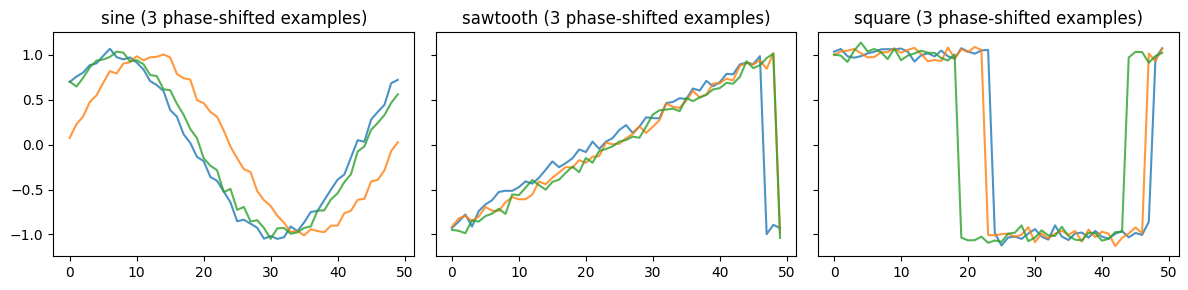

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3), sharey=True)
for ax, family, name in zip(axes, (0, 12, 24), ("sine", "sawtooth", "square"), strict=False):
    for offset in range(3):
        ax.plot(series[family + offset], alpha=0.8)
    ax.set_title(f"{name} (3 phase-shifted examples)")
plt.tight_layout()
plt.show()

## DTW distance matrix

Reordered by the true family, the DTW distances show a clear block structure: low distance within a shape family, high distance across families, despite the phase shifts.

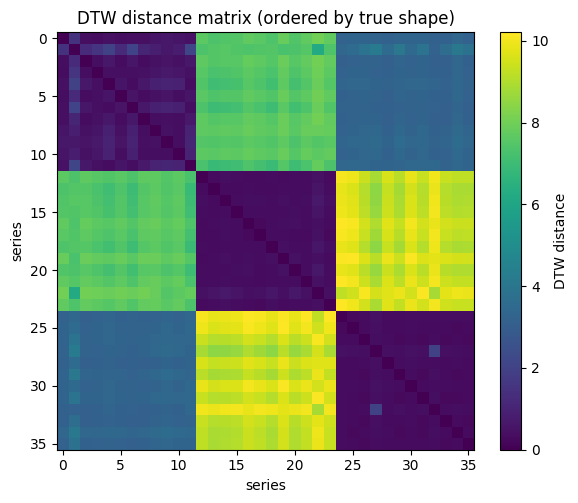

In [4]:
dtw = dtw_distance_matrix(series, band=8)
order = np.argsort(truth)

fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(dtw[order][:, order], cmap="viridis")
ax.set_title("DTW distance matrix (ordered by true shape)")
ax.set_xlabel("series")
ax.set_ylabel("series")
fig.colorbar(image, label="DTW distance")
plt.tight_layout()
plt.show()

## Cluster with DTW

In [5]:
dtw_labels = cluster_time_series(series, n_clusters=3, band=8)
print(f"DTW clustering ARI vs true shapes: {adjusted_rand_score(truth, dtw_labels):.3f}")

DTW clustering ARI vs true shapes: 1.000


## Baseline: Euclidean distance

The natural baseline clusters the same series with point-by-point Euclidean distance. Because it cannot absorb the phase shifts, it mixes the shape families together.

In [6]:
euclidean = squareform(pdist(series, metric="euclidean"))
euclidean_labels = AgglomerativeClustering(
    n_clusters=3, metric="precomputed", linkage="average"
).fit_predict(euclidean)

print(f"DTW       ARI: {adjusted_rand_score(truth, dtw_labels):.3f}")
print(f"Euclidean ARI: {adjusted_rand_score(truth, euclidean_labels):.3f}")

DTW       ARI: 1.000
Euclidean ARI: 0.589


## Interpretation and limitations

DTW recovers the three shape families almost perfectly, while Euclidean distance is misled by the phase shifts. When the meaningful signal is shape rather than exact timing, the alignment step is what makes the clustering work.

**Limitations.**

- DTW is O(L^2) per pair and the distance matrix is O(n^2) pairs, so it is costly at scale; the Sakoe-Chiba band, lower-bound pruning, or a clustering method that avoids the full matrix become necessary.
- DTW is invariant to time shifts but not to amplitude scaling; z-normalise series first if only the shape matters.
- An over-wide band allows pathological alignments (matching a peak to a trough); the band encodes a real assumption about how much warping is plausible.
- DTW is not a true metric (it can violate the triangle inequality), so distance-based methods that assume metric structure should be used with care.